In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/exchange_rate.csv")

In [8]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

In [9]:
print(df.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None


In [11]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [12]:
print(df.isnull().sum())

Ex_rate    0
dtype: int64


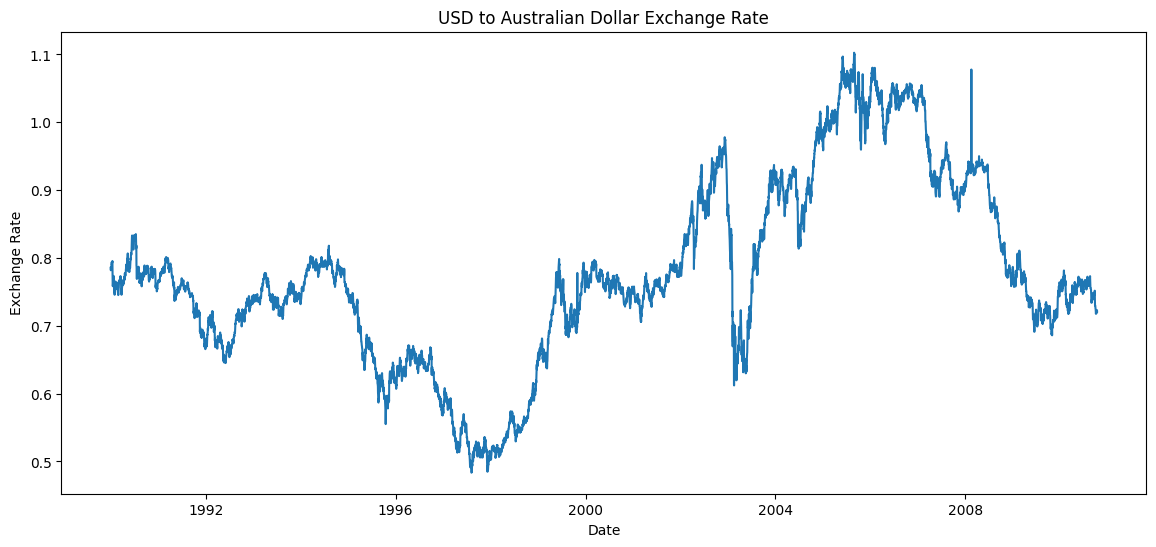

In [13]:
#Time Series Visualization
plt.figure(figsize=(14,6))
plt.plot(df['Ex_rate'])
plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

In [14]:
print(df.isnull().sum())

Ex_rate    0
dtype: int64


In [15]:
df['Ex_rate'] = df['Ex_rate'].fillna(method='ffill')

/tmp/ipykernel_12113/3777789508.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Ex_rate'] = df['Ex_rate'].fillna(method='ffill')


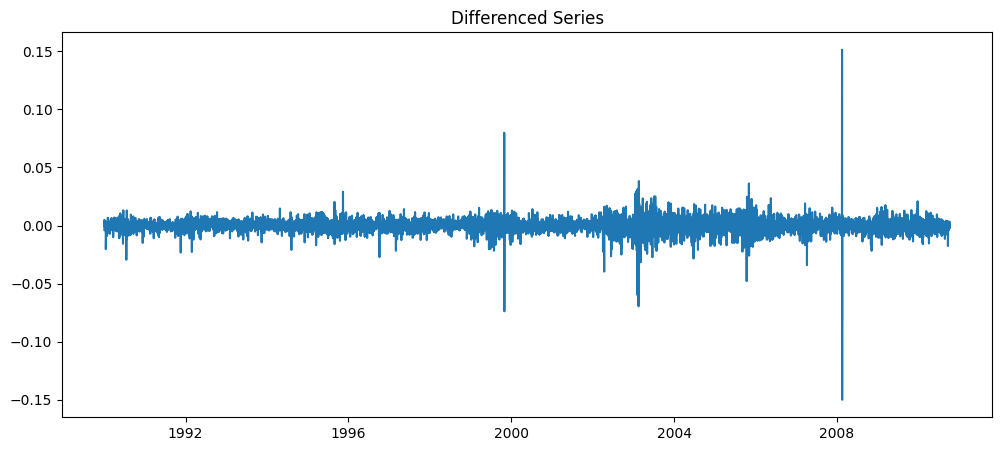

In [18]:
df_diff = df['Ex_rate'].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

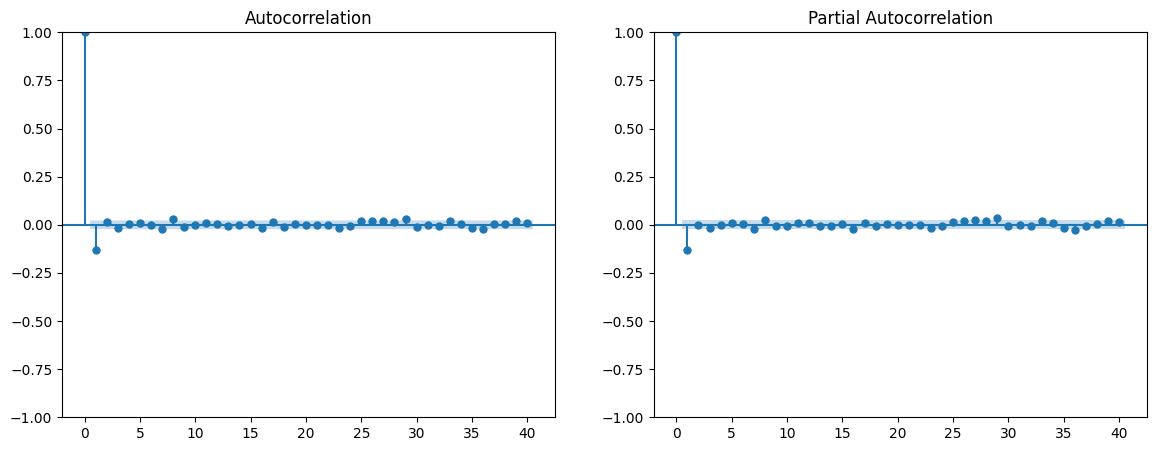

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(df_diff, lags=40, ax=ax[0])
plot_pacf(df_diff, lags=40, ax=ax[1])

plt.show()

In [21]:
#Train-Test Split
train_size = int(len(df)*0.80)
train = df[:train_size]
test = df[train_size:]
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (6070, 1)
Test Shape : (1518, 1)


In [23]:
from statsmodels.tsa.arima.model import ARIMA
#Build ARIMA Model
arima_model = ARIMA(train['Ex_rate'],order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 14 Jun 2026   AIC                         -45432.092
Time:                        02:00:38   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

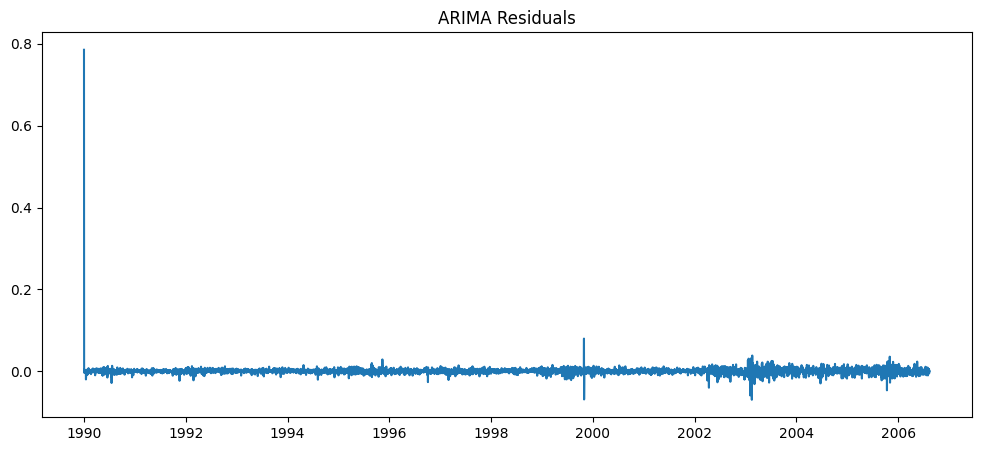

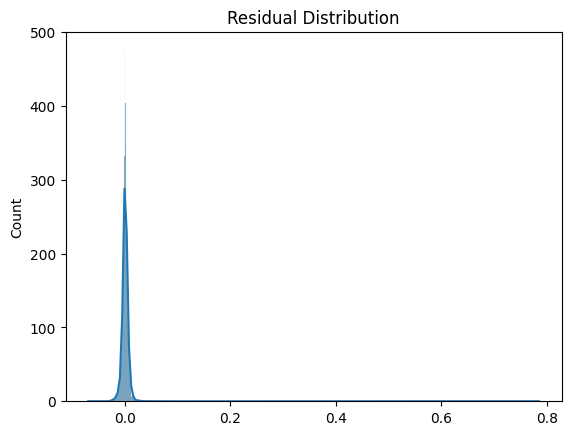

In [24]:
#ARIMA Residual Diagnostics
residuals = arima_fit.resid
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [25]:
#ARIMA Forecasting
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast,index=test.index)

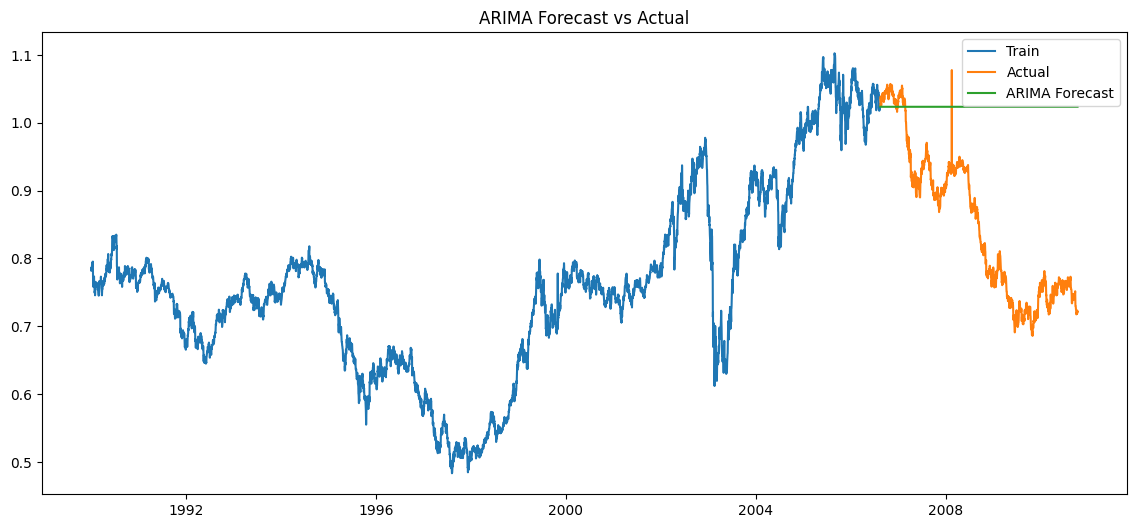

In [26]:
#Visualize ARIMA Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index,train['Ex_rate'],label='Train')
plt.plot(test.index,test['Ex_rate'],label='Actual')
plt.plot(test.index,arima_forecast,label='ARIMA Forecast')
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
#Exponential Smoothing Model
exp_model = ExponentialSmoothing(train['Ex_rate'],trend='add',seasonal=None)
exp_fit = exp_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
#Exponential Smoothing Forecast
exp_forecast = exp_fit.forecast(len(test))
exp_forecast = pd.Series(exp_forecast,index=test.index)

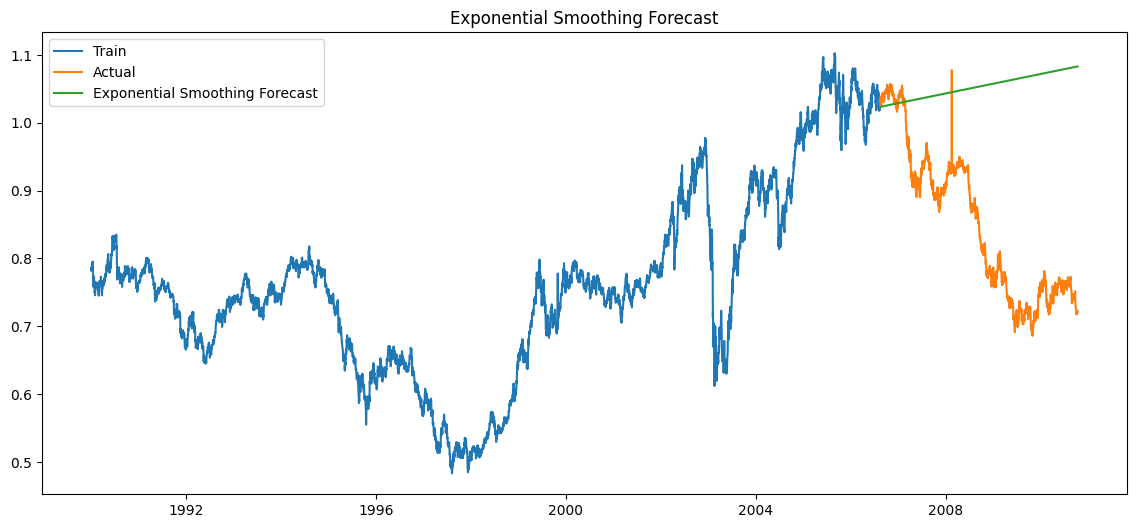

In [30]:
plt.figure(figsize=(14,6))
plt.plot(train.index,train['Ex_rate'],label='Train')
plt.plot(test.index,test['Ex_rate'],label='Actual')
plt.plot(test.index,exp_forecast,label='Exponential Smoothing Forecast')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error # Ensure these are imported

def calculate_rmse(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual-predicted)/actual)) * 100
    return mae,rmse,mape

In [45]:
#Evaluate ARIMA
arima_mae, arima_rmse, arima_mape = calculate_rmse(test['Ex_rate'],arima_forecast)
print("ARIMA Results")
print("MAE :", arima_mae)
print("RMSE :", arima_rmse)
print("MAPE :", arima_mape)

ARIMA Results
MAE : 0.17770970449121345
RMSE : 0.2054366965966928
MAPE : 22.797966173811552


In [47]:
#Evaluate Exponential Smoothing
exp_mae, exp_rmse, exp_mape = calculate_rmse(test['Ex_rate'],exp_forecast)
print("Exponential Smoothing Results")
print("MAE :", exp_mae)
print("RMSE :", exp_rmse)
print("MAPE :", exp_mape)

Exponential Smoothing Results
MAE : 0.20659619114093827
RMSE : 0.23910443161792286
MAPE : 26.50866379878783


In [48]:
#Model Comparison Table
comparison = pd.DataFrame({
    "Model" : ["ARIMA","Exponential Smoothing"],
    "MAE" : [arima_mae,exp_mae],
    "RMSE" : [arima_rmse,exp_rmse],
    "MAPE" : [arima_mape,exp_mape]
})
print(comparison)

                   Model       MAE      RMSE       MAPE
0                  ARIMA  0.177710  0.205437  22.797966
1  Exponential Smoothing  0.206596  0.239104  26.508664


In [49]:
#Best Model Selection
best_model = comparison.loc[comparison['RMSE'].idxmin(),'Model']
print("Best Performing Model :", best_model)

Best Performing Model : ARIMA


In [ ]:
###Conclusion
Compare MAE, RMSE and MAPE.
The model with the lowest RMSE and MAPE is considered the best.
Based on the evaluation metrics, select the better forecasting model for exchange rate prediction.
###